<a href="https://colab.research.google.com/github/yejinPARK48/michigan_building_detection/blob/main/02_data_curation/Pre_Phase_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pre-Phase 3: Curated Tile Dataset Construction

**Input**: Tile images & masks from Phase 1 & 2  
**Output**: `curated_ids_stable.csv`, `curated_ids_sparse.csv`, train/val split

---
## Background

Analysis of Phase 1 & 2 outputs showed that the majority of generated tiles contain no buildings or very few buildings. Using all tiles as-is leads to:
- Severe **class imbalance** (background >> building pixels)
- U-Net converging to a **trivial solution** (predicting all background)
- **IoU ≈ 0**

## Strategy

All tiles are classified into three tiers based on building pixel ratio, then sampled at different rates to create a balanced training set.

```
Tier      | Building Ratio  | Sampling
----------|-----------------|-----------------------------
Dense     | >= 0.05         | All tiles kept
Sparse    | 0.001 ~ 0.05    | Sampled at 1.0x or 1.3x dense count
Empty     | < 0.001        | Sampled at 0.2x or 0.3x dense count
```

Two sampling strategies are available:
- **stable**: sparse 1×, empty 0.2× — conservative, stable training
- **sparse**: sparse 1.3×, empty 0.3× — emphasizes sparse tiles


## 0. Installation

In [ ]:
import importlib
if importlib.util.find_spec('segmentation_models_pytorch') is None:
    !pip install segmentation-models-pytorch albumentations -q
if importlib.util.find_spec('cv2') is None:
    !pip install opencv-python-headless scikit-image -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 9.0 MB/s eta 0:00:00


## 0-1. Imports

In [ ]:
import os, random, warnings
warnings.filterwarnings('ignore')

import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 0-2. Paths & Config

In [ ]:
# ── Phase 1 & 2 output paths ──────────────────────────────────
BASE_DIR      = '/content/drive/MyDrive/michigan_unet_project'
TILE_IMG_DIR  = f'{BASE_DIR}/tiles/images'   # NAIP tiles from Phase 2
TILE_MASK_DIR = f'{BASE_DIR}/tiles/masks'    # Binary masks from Phase 2
META_DIR      = f'{BASE_DIR}/metadata'       # train_ids.csv, val_ids.csv

# ── Pre-Phase 3 output path ───────────────────────────────────
CURATED_DIR   = f'{BASE_DIR}/curated'        # Curated ID lists saved here

os.makedirs(CURATED_DIR, exist_ok=True)

# ── Check tile counts ─────────────────────────────────────────
all_img_files  = sorted(Path(TILE_IMG_DIR).glob('*.png'))
all_mask_files = sorted(Path(TILE_MASK_DIR).glob('*.png'))
print(f'Images : {len(all_img_files):,}')
print(f'Masks  : {len(all_mask_files):,}')

Images : 8,243
Masks  : 8,243


---
## P3-1. Building Ratio + Image QC Score Calculation

For each tile, compute:
- **building_ratio**: fraction of mask pixels that are buildings
- **QC scores**: blur (Laplacian variance), brightness, stripe artifacts

Tiles failing QC thresholds are excluded from training.

In [ ]:
random.seed(42)

img_ids     = {p.stem for p in all_img_files}
mask_ids    = {p.stem for p in all_mask_files}
valid_stems = sorted(img_ids & mask_ids)
print(f'Valid image-mask pairs: {len(valid_stems):,}')

def get_qc_scores(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    lap_var        = cv2.Laplacian(gray, cv2.CV_64F).var()
    mean_intensity = gray.mean()
    row_std        = gray.mean(axis=1).std()
    col_std        = gray.mean(axis=0).std()
    stripe_score   = max(row_std, col_std)
    return lap_var, mean_intensity, stripe_score

tile_stats = []
for stem in valid_stems:
    img = np.array(Image.open(f'{TILE_IMG_DIR}/{stem}.png').convert('RGB'))
    msk = np.array(Image.open(f'{TILE_MASK_DIR}/{stem}.png').convert('L'))

    ratio                           = (msk > 127).sum() / msk.size
    lap_var, mean_intensity, stripe = get_qc_scores(img)

    tile_stats.append({
        'tile_id'        : stem,
        'building_ratio' : ratio,
        'lap_var'        : lap_var,
        'mean_intensity' : mean_intensity,
        'stripe_score'   : stripe
    })

df_stats = pd.DataFrame(tile_stats)

# ── QC thresholds ─────────────────────────────────────────────
BLUR_THR   = 20
DARK_THR   = 20
BRIGHT_THR = 235
STRIPE_THR = 25

df_stats['qc_pass'] = (
    (df_stats['lap_var']        > BLUR_THR)   &
    (df_stats['mean_intensity'] > DARK_THR)   &
    (df_stats['mean_intensity'] < BRIGHT_THR) &
    (df_stats['stripe_score']   < STRIPE_THR)
)

print('\n[QC Results]')
print(df_stats['qc_pass'].value_counts())
print(f"QC fail count: {(~df_stats['qc_pass']).sum():,}")

df_stats_clean = df_stats[df_stats['qc_pass']].copy()
print(f'\nTiles after QC: {len(df_stats_clean):,}')

# ── Tier classification (updated thresholds) ──────────────────
# Empty : < 0.001  (previously 0.005 — too lenient)
# Sparse: 0.001 ~ 0.05
# Dense : >= 0.05
df_stats_clean['tier'] = pd.cut(
    df_stats_clean['building_ratio'],
    bins=[-1, 0.001, 0.05, 1.0],
    labels=['empty', 'sparse', 'dense']
)

print('\n[Tier Distribution (after QC)]')
print(df_stats_clean['tier'].value_counts())
print(f"\nEmpty threshold : < 0.001  (previously 0.005)")
print(f"Sparse threshold: 0.001 ~ 0.05")
print(f"Dense threshold : >= 0.05")

df_stats.to_csv(f'{CURATED_DIR}/tile_stats_with_qc.csv', index=False)
df_stats_clean.to_csv(f'{CURATED_DIR}/tile_stats_clean.csv', index=False)
print(f'\nSaved → {CURATED_DIR}/tile_stats_with_qc.csv')
print(f'Saved → {CURATED_DIR}/tile_stats_clean.csv')

Valid image-mask pairs: 8,243

[QC Results]
qc_pass
True     7462
False     781
Name: count, dtype: int64
QC fail count: 781

Tiles after QC: 7,462

[Tier Distribution (after QC)]
tier
empty     4010
sparse    2490
dense      962
Name: count, dtype: int64

Empty threshold : < 0.001  (previously 0.005)
Sparse threshold: 0.001 ~ 0.05
Dense threshold : >= 0.05

Saved → /content/drive/MyDrive/michigan_unet_project/curated/tile_stats_with_qc.csv
Saved → /content/drive/MyDrive/michigan_unet_project/curated/tile_stats_clean.csv


## P3-2. Distribution Visualization

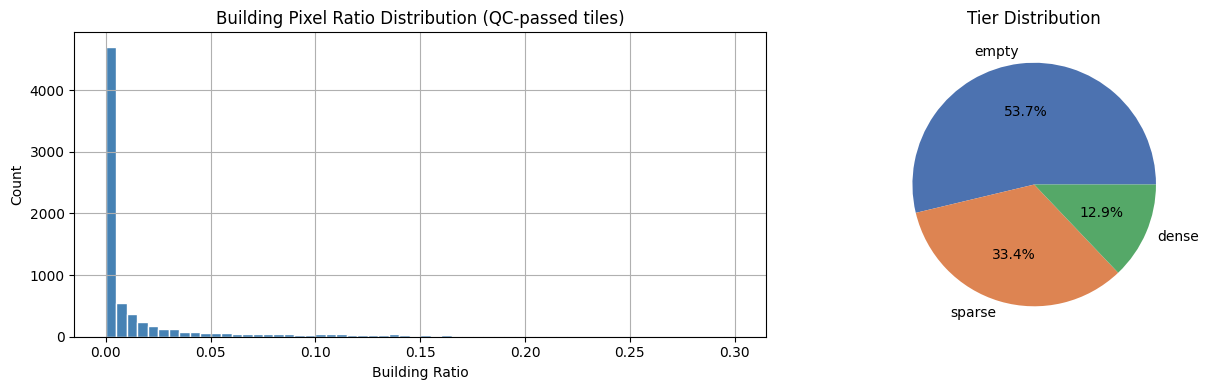

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_stats_clean['building_ratio'].clip(upper=0.3).hist(
    ax=axes[0], bins=60, color='steelblue', edgecolor='white'
)
axes[0].set_title('Building Pixel Ratio Distribution (QC-passed tiles)')
axes[0].set_xlabel('Building Ratio')
axes[0].set_ylabel('Count')

tier_counts = df_stats_clean['tier'].value_counts()
axes[1].pie(
    tier_counts,
    labels=tier_counts.index,
    autopct='%1.1f%%',
    colors=['#4C72B0', '#DD8452', '#55A868']
)
axes[1].set_title('Tier Distribution')

plt.tight_layout()
plt.savefig(f'{CURATED_DIR}/tier_distribution.png', dpi=100)
plt.show()

## P3-3. Tier-Based Sampling

Two strategies available — run both to save both ID lists.

| Strategy | Sparse ratio | Empty ratio | Description |
|----------|-------------|-------------|-------------|
| **stable** | 1.0× dense | 0.2× dense | Conservative, stable training |
| **sparse** | 1.3× dense | 0.3× dense | Emphasizes sparse tile coverage |


In [ ]:
random.seed(42)

dense_ids  = df_stats_clean[df_stats_clean['tier'] == 'dense' ]['tile_id'].tolist()
sparse_ids = df_stats_clean[df_stats_clean['tier'] == 'sparse']['tile_id'].tolist()
empty_ids  = df_stats_clean[df_stats_clean['tier'] == 'empty' ]['tile_id'].tolist()

for SAMPLING_VERSION, n_sparse_ratio, n_empty_ratio in [
    ('stable', 1.0, 0.2),
    ('sparse', 1.3, 0.3),
]:
    n_dense  = len(dense_ids)
    n_sparse = min(len(sparse_ids), int(n_dense * n_sparse_ratio))
    n_empty  = min(len(empty_ids),  int(n_dense * n_empty_ratio))

    curated = (
        dense_ids +
        random.sample(sparse_ids, n_sparse) +
        random.sample(empty_ids,  n_empty)
    )
    random.shuffle(curated)

    print(f'[{SAMPLING_VERSION}]')
    print(f'  Dense  (all)     : {n_dense:,}')
    print(f'  Sparse (sampled) : {n_sparse:,}')
    print(f'  Empty  (sampled) : {n_empty:,}')
    print(f'  Total curated    : {len(curated):,}')

    out_path = f'{CURATED_DIR}/curated_ids_{SAMPLING_VERSION}.csv'
    pd.Series(curated).to_csv(out_path, index=False, header=False)
    print(f'  Saved → {out_path}\n')

# Use stable as default for downstream steps
SAMPLING_VERSION = 'stable'
curated_ids = pd.read_csv(
    f'{CURATED_DIR}/curated_ids_{SAMPLING_VERSION}.csv', header=None
)[0].astype(str).tolist()
print(f'Active strategy: {SAMPLING_VERSION} ({len(curated_ids):,} tiles)')

[stable]
  Dense  (all)     : 962
  Sparse (sampled) : 962
  Empty  (sampled) : 192
  Total curated    : 2,116
  Saved → /content/drive/MyDrive/michigan_unet_project/curated/curated_ids_stable.csv

[sparse]
  Dense  (all)     : 962
  Sparse (sampled) : 1,250
  Empty  (sampled) : 288
  Total curated    : 2,500
  Saved → /content/drive/MyDrive/michigan_unet_project/curated/curated_ids_sparse.csv

Active strategy: stable (2,116 tiles)


## P3-4. Sample Visualization (Sanity Check)

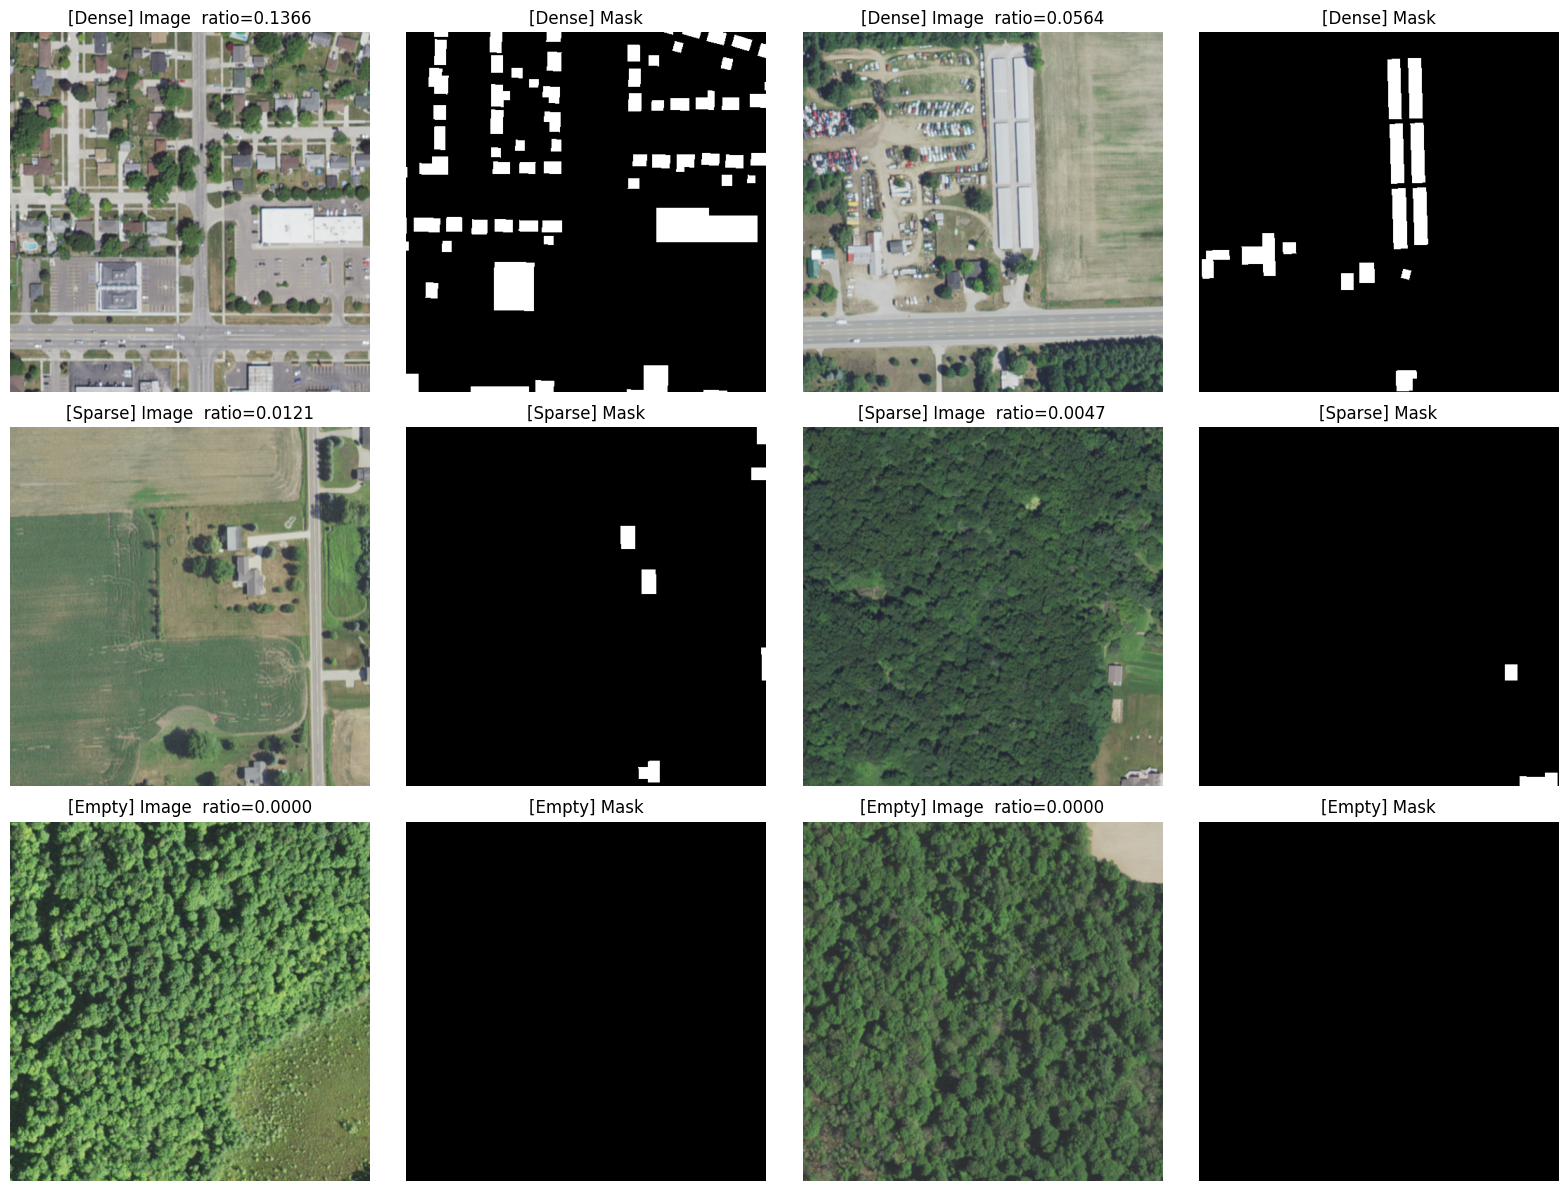

In [ ]:
samples = {
    'Dense':  random.sample(dense_ids,  min(2, len(dense_ids))),
    'Sparse': random.sample(sparse_ids, min(2, len(sparse_ids))),
    'Empty':  random.sample(empty_ids,  min(2, len(empty_ids))),
}

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for row_i, (tier, ids) in enumerate(samples.items()):
    for col_i, tid in enumerate(ids):
        img   = np.array(Image.open(f'{TILE_IMG_DIR}/{tid}.png').convert('RGB'))
        mask  = np.array(Image.open(f'{TILE_MASK_DIR}/{tid}.png').convert('L'))
        ratio = df_stats_clean[df_stats_clean['tile_id'] == tid]['building_ratio'].values[0]

        ax_img  = axes[row_i][col_i * 2]
        ax_mask = axes[row_i][col_i * 2 + 1]

        ax_img.imshow(img)
        ax_img.set_title(f'[{tier}] Image  ratio={ratio:.4f}')
        ax_img.axis('off')

        ax_mask.imshow(mask > 127, cmap='gray')
        ax_mask.set_title(f'[{tier}] Mask')
        ax_mask.axis('off')

plt.tight_layout()
plt.savefig(f'{CURATED_DIR}/curated_samples.png', dpi=100)
plt.show()

## P3-5. Train / Val Split

Intersect curated IDs with the existing Phase 2 train/val split to preserve the original split boundary.  
If no Phase 2 split exists, create a new 80/20 split.

In [ ]:
train_csv = f'{META_DIR}/train_ids.csv'
val_csv   = f'{META_DIR}/val_ids.csv'

if os.path.exists(train_csv) and os.path.exists(val_csv):
    phase2_train = set(pd.read_csv(train_csv, header=None)[0].astype(str).tolist())
    phase2_val   = set(pd.read_csv(val_csv,   header=None)[0].astype(str).tolist())
    curated_set  = set(curated_ids)
    train_ids    = sorted(phase2_train & curated_set)
    val_ids      = sorted(phase2_val   & curated_set)
    print('Applied Phase 2 split with curated intersection')
else:
    random.seed(42)
    shuffled  = curated_ids.copy()
    random.shuffle(shuffled)
    n_train   = int(len(shuffled) * 0.8)
    train_ids = shuffled[:n_train]
    val_ids   = shuffled[n_train:]
    print('Created new 80/20 Train/Val split')

print(f'Train: {len(train_ids):,} | Val: {len(val_ids):,}')

def mean_ratio(ids):
    return df_stats_clean[df_stats_clean['tile_id'].isin(ids)]['building_ratio'].mean()

print(f'Train mean building ratio : {mean_ratio(train_ids):.5f}')
print(f'Val   mean building ratio : {mean_ratio(val_ids):.5f}')

# Save curated train/val splits
pd.Series(train_ids).to_csv(f'{CURATED_DIR}/curated_train_ids.csv', index=False, header=False)
pd.Series(val_ids).to_csv(f'{CURATED_DIR}/curated_val_ids.csv',   index=False, header=False)
print(f'\nSaved → {CURATED_DIR}/curated_train_ids.csv')
print(f'Saved → {CURATED_DIR}/curated_val_ids.csv')

Applied Phase 2 split with curated intersection
Train: 1,696 | Val: 420
Train mean building ratio : 0.06057
Val   mean building ratio : 0.05955

Saved → /content/drive/MyDrive/michigan_unet_project/curated/curated_train_ids.csv
Saved → /content/drive/MyDrive/michigan_unet_project/curated/curated_val_ids.csv


## Summary

In [ ]:
print('=' * 55)
print('Pre-Phase 3 Complete')
print('=' * 55)
print(f'Total QC-passed tiles : {len(df_stats_clean):,}')
print(f'  Dense               : {len(dense_ids):,}')
print(f'  Sparse              : {len(sparse_ids):,}')
print(f'  Empty               : {len(empty_ids):,}')
print()
for v in ['stable', 'sparse']:
    path = f'{CURATED_DIR}/curated_ids_{v}.csv'
    if os.path.exists(path):
        n = len(pd.read_csv(path, header=None))
        print(f'curated_ids_{v}.csv : {n:,} tiles')
print()
print(f'Train split : {len(train_ids):,}')
print(f'Val   split : {len(val_ids):,}')
print()
print('Output files:')
print(f'  {CURATED_DIR}/tile_stats_clean.csv')
print(f'  {CURATED_DIR}/curated_ids_stable.csv')
print(f'  {CURATED_DIR}/curated_ids_sparse.csv')
print(f'  {CURATED_DIR}/curated_train_ids.csv')
print(f'  {CURATED_DIR}/curated_val_ids.csv')
print('=' * 55)

Pre-Phase 3 Complete
Total QC-passed tiles : 7,462
  Dense               : 962
  Sparse              : 2,490
  Empty               : 4,010

curated_ids_stable.csv : 2,116 tiles
curated_ids_sparse.csv : 2,500 tiles

Train split : 1,696
Val   split : 420

Output files:
  /content/drive/MyDrive/michigan_unet_project/curated/tile_stats_clean.csv
  /content/drive/MyDrive/michigan_unet_project/curated/curated_ids_stable.csv
  /content/drive/MyDrive/michigan_unet_project/curated/curated_ids_sparse.csv
  /content/drive/MyDrive/michigan_unet_project/curated/curated_train_ids.csv
  /content/drive/MyDrive/michigan_unet_project/curated/curated_val_ids.csv
